# 04 · Behaviour Tables and the First Real Signal

Notebook 03 closed a door: at the daily up/down scale, markets carry no
deterministic rule. This notebook opens a new one. The mistake was to look only at
the **direction** bit. If we instead write each move in **several bits** and study
the *size* of moves, a genuine, self-similar signal appears — and it is
forecastable.

Two ideas:

1. a **behaviour table** describes *how* the ones of a pattern are laid out, without
   assuming any gate — it compresses structure and refuses to compress noise;
2. a **multi-bit binarisation** splits each move into a *direction* bit and a
   *magnitude* (volatility) bit. The direction bit is inert. The volatility bit is
   where the order lives.

In [1]:
# --- Run me first: make this notebook executable from anywhere -----------------
import os, sys

def _find_root(start=None):
    d = os.path.abspath(start or os.getcwd())
    while True:
        if os.path.isfile(os.path.join(d, "PROTOCOL_order_discovery.md")):
            return d
        parent = os.path.dirname(d)
        if parent == d:
            break
        d = parent
    for cand in [os.path.expanduser("~/Documents/projects/CausalBool/index-deconvolution")]:
        if os.path.isfile(os.path.join(cand, "PROTOCOL_order_discovery.md")):
            return cand
    raise RuntimeError("Could not locate the index-deconvolution root. "
                       "Set ROOT = '/path/to/index-deconvolution' by hand and re-run.")

ROOT = _find_root()
for _sub in ["src", "level2", "level3", "level4", "level5", "level6", "level7", "level8"]:
    _p = os.path.join(ROOT, _sub)
    if _p not in sys.path:
        sys.path.insert(0, _p)

DATA       = os.path.join(ROOT, "finance", "data")          # 23 tickers, 3 years
DATA_LONG  = os.path.join(ROOT, "finance", "data_long")     # 12 instruments, ~30+ years
BIO        = os.path.join(os.path.dirname(ROOT), "data", "bio", "raw")  # .bnet networks

import matplotlib.pyplot as plt
import numpy as np

# a clean, consistent didactic style
plt.rcParams.update({
    "figure.figsize": (9, 4.2), "figure.dpi": 110,
    "axes.grid": True, "grid.alpha": 0.25, "axes.spines.top": False,
    "axes.spines.right": False, "font.size": 11, "axes.titlesize": 12,
    "axes.titleweight": "bold", "image.cmap": "magma",
})
INK, HL, OK, BAD = "#20222b", "#c1121f", "#2a9d8f", "#e07a1f"
print("repo root :", ROOT)
print("ready. matplotlib + numpy loaded; code layers on the path.")

repo root : /Users/alberto/Documents/projects/CausalBool/index-deconvolution
ready. matplotlib + numpy loaded; code layers on the path.


## 1. Two units from one number: direction vs magnitude

For a price series we take each day's move. Its **sign** is one bit (up/down). Its
**magnitude** — is the move big or small? — is another bit. Let us look at both for
one instrument.

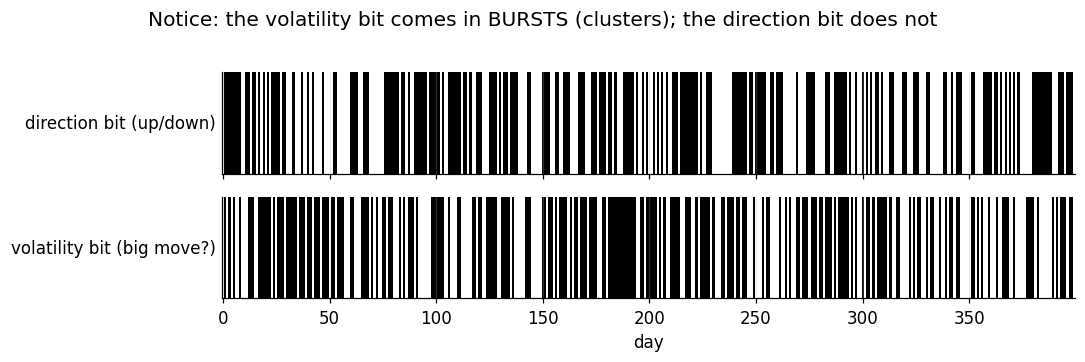

In [2]:
from controls import load_long_sequences          # long daily series, ~30 years
from binarise import sign_bit, top_magnitude_bit
from unit_survival import lag1_autocorr, longest_run_of_ones

series = load_long_sequences()
s = series["SP500"]
sign = sign_bit(s)
vol  = top_magnitude_bit(s, scale_free=True)       # 1 = a big move that day

fig, axes = plt.subplots(2, 1, figsize=(10, 3.2), sharex=True)
for ax, bits, t in zip(axes, [sign, vol], ["direction bit (up/down)", "volatility bit (big move?)"]):
    ax.imshow([bits[:400]], cmap="binary", aspect="auto", interpolation="nearest")
    ax.set_yticks([]); ax.set_ylabel(t, rotation=0, ha="right", va="center")
axes[1].set_xlabel("day")
plt.suptitle("Notice: the volatility bit comes in BURSTS (clusters); the direction bit does not", y=1.02)
plt.tight_layout(); plt.show()

## 2. Which unit carries order? Compare each bit to its own shuffle

A **time-shuffle** keeps the number of 1s but scrambles their order. If a bit has no
temporal structure, it looks just like its shuffle. We measure two things — how much
the ones **cluster** (longest run) and their **persistence** (lag-1 correlation) —
as a *z-score* against the shuffle. Big z = real structure.

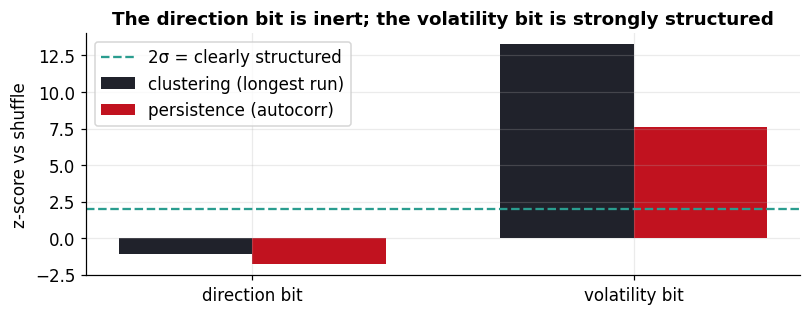

In [3]:
import random, statistics
rng = random.Random(0)

def z_vs_shuffle(bits, stat, k=200):
    obs = stat(bits); b = bits[:]; draws=[]
    for _ in range(k):
        rng.shuffle(b); draws.append(stat(b))
    sd = statistics.pstdev(draws)
    return (obs - statistics.mean(draws))/sd if sd else 0.0

rows = []
for name, bits in [("direction bit", sign), ("volatility bit", vol)]:
    rows.append((name,
                 z_vs_shuffle(bits, longest_run_of_ones),
                 z_vs_shuffle(bits, lag1_autocorr)))

fig, ax = plt.subplots(figsize=(7.5, 3))
x = np.arange(2); wdt = 0.35
ax.bar(x-wdt/2, [r[1] for r in rows], wdt, label="clustering (longest run)", color=INK)
ax.bar(x+wdt/2, [r[2] for r in rows], wdt, label="persistence (autocorr)", color=HL)
ax.axhline(2, ls="--", color=OK, label="2σ = clearly structured")
ax.set_xticks(x); ax.set_xticklabels([r[0] for r in rows]); ax.set_ylabel("z-score vs shuffle")
ax.legend(); ax.set_title("The direction bit is inert; the volatility bit is strongly structured")
plt.tight_layout(); plt.show()

## 3. The structure is *self-similar* — it lives at every scale

Here is the signature that recurs through the rest of the programme. Count how many
big-move days fall in windows of growing size, and measure the **spread** of those
counts relative to their average (the *index of dispersion*). For a memoryless
process it stays flat. For the real volatility bit it **grows with the window** — the
clustering is present at every scale at once. That is what "self-similar" means.

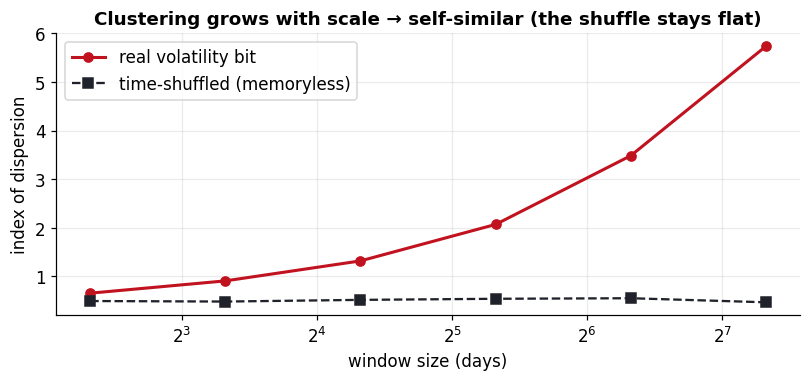

Hurst exponent of the volatility bit: 0.804  (0.5 = no memory, >0.5 = long memory)


In [4]:
def index_of_dispersion(bits, w):
    counts = [sum(bits[i:i+w]) for i in range(0, len(bits)-w+1, w)]
    m = statistics.mean(counts)
    return statistics.pvariance(counts)/m if m else float("nan")

windows = [5, 10, 20, 40, 80, 160]
real = [index_of_dispersion(vol, w) for w in windows]
shuf = vol[:]; rng.shuffle(shuf)
null = [index_of_dispersion(shuf, w) for w in windows]

fig, ax = plt.subplots(figsize=(7.5, 3.6))
ax.plot(windows, real, "o-", color=HL, lw=2, label="real volatility bit")
ax.plot(windows, null, "s--", color=INK, label="time-shuffled (memoryless)")
ax.set_xscale("log", base=2); ax.set_xlabel("window size (days)"); ax.set_ylabel("index of dispersion")
ax.legend(); ax.set_title("Clustering grows with scale → self-similar (the shuffle stays flat)")
plt.tight_layout(); plt.show()

from occurrence_arithmetic import hurst_aggregated_variance
print(f"Hurst exponent of the volatility bit: {hurst_aggregated_variance(vol):.3f}  (0.5 = no memory, >0.5 = long memory)")

## 4. The pay-off: volatility is forecastable, direction is not

We commit a simple rule on the first 60% of history and test it on the unseen last
40%: predict the next volatility bit from recent ones. We compare the real edge to
the shuffle. We do the same for the direction bit as a control.

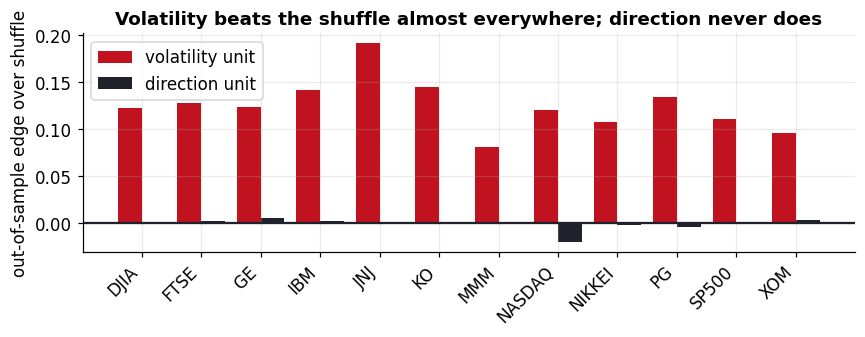

volatility: mean edge +0.125, beats shuffle on 12/12
direction : mean edge -0.001, beats shuffle on 7/12


In [5]:
from exp13_forecast import fit_and_test

def edge_vs_shuffle(bits, k=30):
    real = fit_and_test(bits)["edge"]
    b = bits[:]; ds=[]
    for _ in range(k):
        rng.shuffle(b); ds.append(fit_and_test(b)["edge"])
    return real - statistics.mean(ds)

vol_edges  = [edge_vs_shuffle(top_magnitude_bit(x, scale_free=True)) for x in series.values()]
sign_edges = [edge_vs_shuffle(sign_bit(x)) for x in series.values()]

fig, ax = plt.subplots(figsize=(8, 3.2))
xs = np.arange(len(series))
ax.bar(xs-0.2, vol_edges, 0.4, color=HL, label="volatility unit")
ax.bar(xs+0.2, sign_edges, 0.4, color=INK, label="direction unit")
ax.axhline(0, color=INK)
ax.set_xticks(xs); ax.set_xticklabels(list(series.keys()), rotation=45, ha="right")
ax.set_ylabel("out-of-sample edge over shuffle"); ax.legend()
ax.set_title("Volatility beats the shuffle almost everywhere; direction never does")
plt.tight_layout(); plt.show()
print(f"volatility: mean edge {np.mean(vol_edges):+.3f}, beats shuffle on {sum(1 for e in vol_edges if e>0)}/{len(vol_edges)}")
print(f"direction : mean edge {np.mean(sign_edges):+.3f}, beats shuffle on {sum(1 for e in sign_edges if e>0)}/{len(sign_edges)}")

## Takeaways

* Splitting each move into **direction** and **magnitude** reveals that the order is
  in the magnitude: the **volatility bit clusters**, self-similarly, at every scale
  (Hurst well above 0.5).
* That structure is **forecastable out of sample** — it beats a shuffle almost
  everywhere — while the direction stays unforecastable.
* We can predict *how big* the next move is, never *which way*.

**Next (05):** we drop binarisation entirely and describe the series by **where its
turning points fall** — the most agnostic view — and find that the information lives
in a *clock*.